In [1]:
from datetime import datetime
import numpy as np             #for numerical computations like log,exp,sqrt etc
import pandas as pd            #for reading & storing data, pre-processing
import matplotlib.pylab as plt #for plotting
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from matplotlib.pylab import rcParams
%matplotlib inline

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('/content/AirPassengers.csv')

In [4]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
df.shape

(144, 2)

In [6]:
df.isnull().sum()

,0
Month,0
#Passengers,0


In [7]:
df.isna().sum()

,0
Month,0
#Passengers,0


In [8]:
# Convert Month into Datetime
df['Month']=pd.to_datetime(df['Month'])

In [9]:
df.head()

,Month,#Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [10]:
df.set_index('Month',inplace=True)

In [11]:
df.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [12]:
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


<Axes: xlabel='Month'>

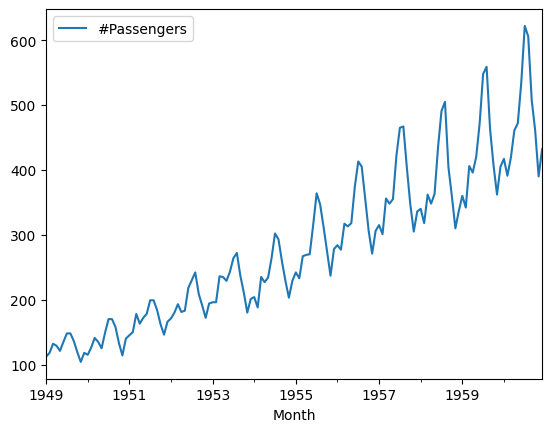

In [13]:
# Visualize the Data
df.plot()

In [14]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

In [15]:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(sales):
    result=adfuller(sales)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [16]:
adfuller_test(df['#Passengers'])

ADF Test Statistic : 0.8153688792060498
p-value : 0.991880243437641
#Lags Used : 13
Number of Observations Used : 130
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [17]:
# Differencing
#Determine rolling statistics
rolmean = df.rolling(window=12).mean() #window size 12 denotes 12 months, giving rolling mean at yearly level
rolstd = df.rolling(window=12).std()

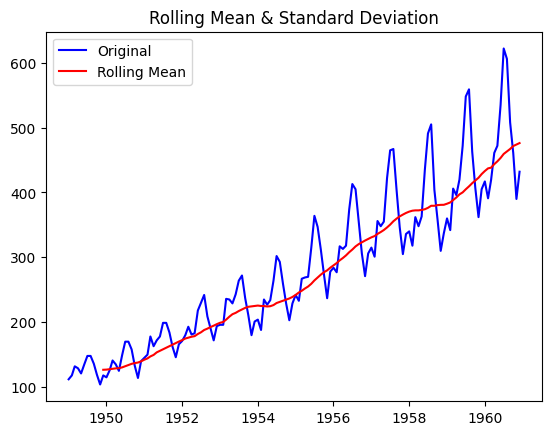

In [18]:
#Plot rolling statistics
orig = plt.plot(df, color='blue', label='Original')
mean = plt.plot(rolmean, color='red', label='Rolling Mean')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation')
plt.show(block=False)

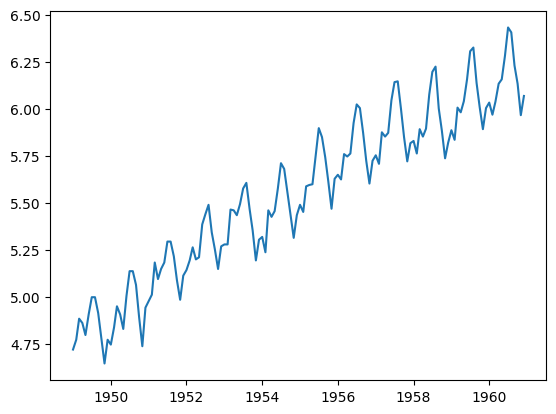

In [19]:
#Estimating trend
df_logScale = np.log(df)
plt.plot(df_logScale)

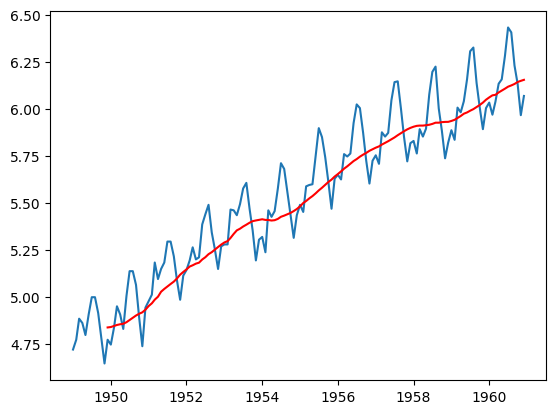

In [20]:
#The below transformation is required to make series stationary
movingAverage = df_logScale.rolling(window=12).mean()
movingSTD = df_logScale.rolling(window=12).std()
plt.plot(df_logScale)
plt.plot(movingAverage, color='red')

In [21]:
df_logScale_ma = df_logScale - movingAverage
df_logScale_ma.head(12)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


In [22]:
#Remove NAN values
df_logScale_ma.dropna(inplace=True)
df_logScale_ma.head(10)

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
1950-05-01,-0.027529
1950-06-01,0.139881
1950-07-01,0.260184
1950-08-01,0.248635


In [23]:
## Again test dickey fuller test
adfuller_test(df_logScale_ma)

ADF Test Statistic : -3.1629079913008833
p-value : 0.022234630001242206
#Lags Used : 13
Number of Observations Used : 119
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


<Axes: xlabel='Month'>

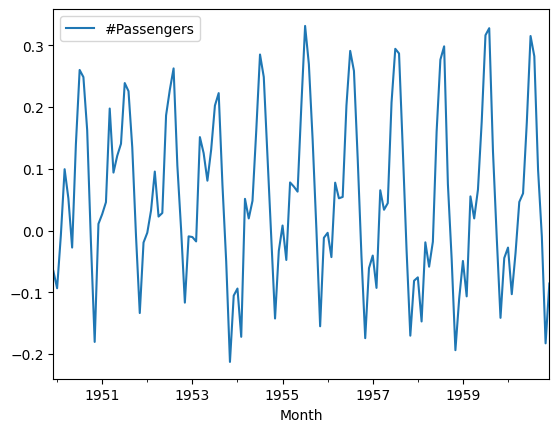

In [24]:
df_logScale_ma.plot()

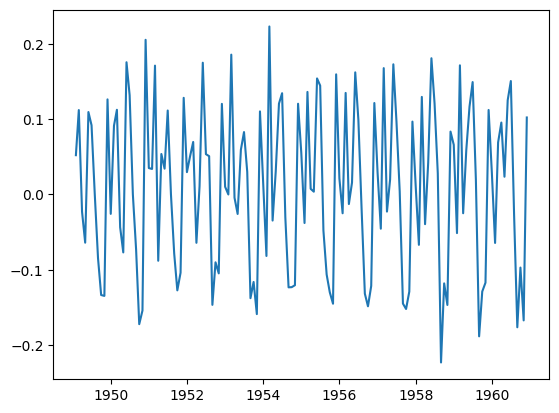

In [25]:
df_logScale_shift = df_logScale - df_logScale.shift()
plt.plot(df_logScale_shift)

<Axes: xlabel='Month'>

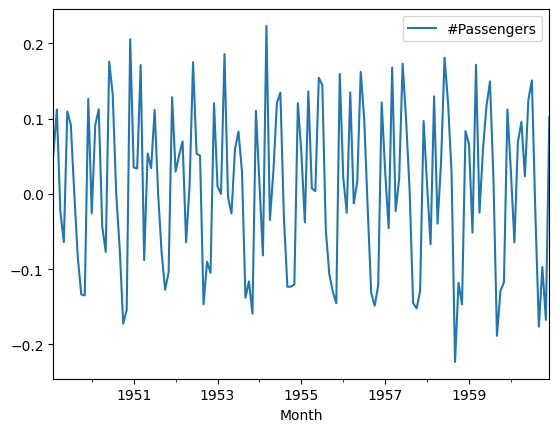

In [26]:
df_logScale_shift.dropna(inplace=True)
df_logScale_shift.plot()

In [27]:
## Again test dickey fuller test
adfuller_test(df_logScale_shift)

ADF Test Statistic : -2.717130598388114
p-value : 0.07112054815086184
#Lags Used : 14
Number of Observations Used : 128
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


In [28]:
# Autocorrelation and Partial Autocorrelation
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

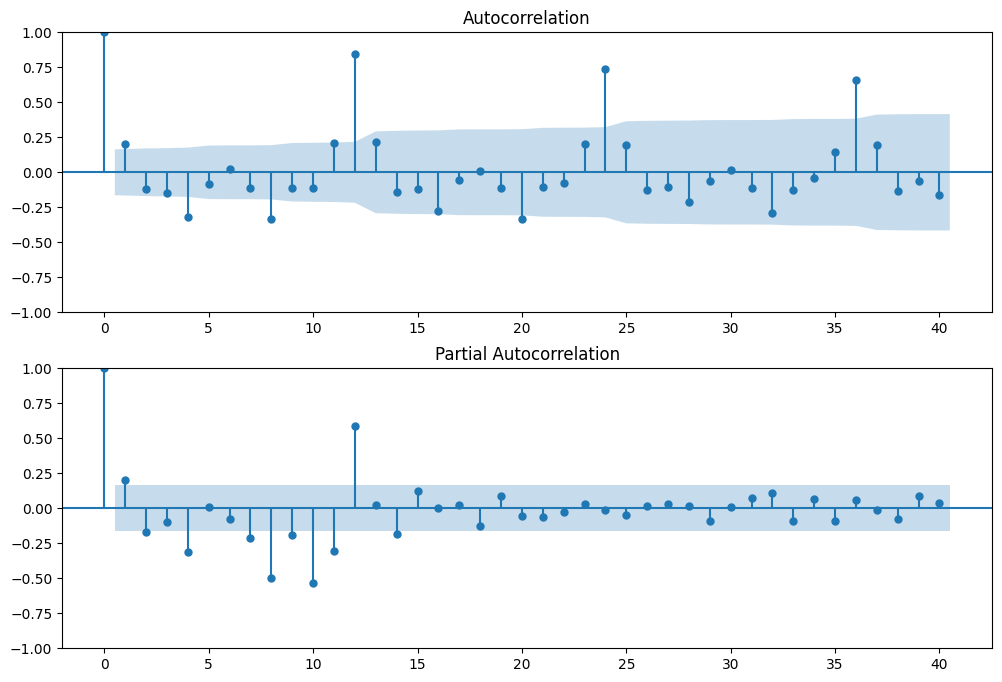

In [29]:
import statsmodels.api as sm

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df_logScale_shift.values.squeeze(),lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df_logScale_shift,lags=40,ax=ax2)

In [30]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df, order=(1, 0, 1)) # Using the updated class
model_fit = model.fit()

In [31]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            #Passengers   No. Observations:                  144
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -700.874
Date:                Mon, 30 Dec 2024   AIC                           1409.749
Time:                        22:09:03   BIC                           1421.628
Sample:                    01-01-1949   HQIC                          1414.576
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        280.3009     56.644      4.948      0.000     169.281     391.321
ar.L1          0.9373      0.028     34.009      0.000       0.883       0.991
ma.L1          0.4264      0.076      5.642      0.000       0.278       0.574
sigma2       968.4365    112.711      8.592      0.000     747.527    1189.346
===================================================================================
Ljung-Box (L1) (Q):                   0.04   Jarque-Bera (JB):                 1.89
Prob(Q):                              0.84   Prob(JB):                         0.39
Heteroskedasticity (H):               6.81   Skew:                             0.26
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.18
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [32]:
model_fit.aic

1409.7487227836145

<Axes: xlabel='Month'>

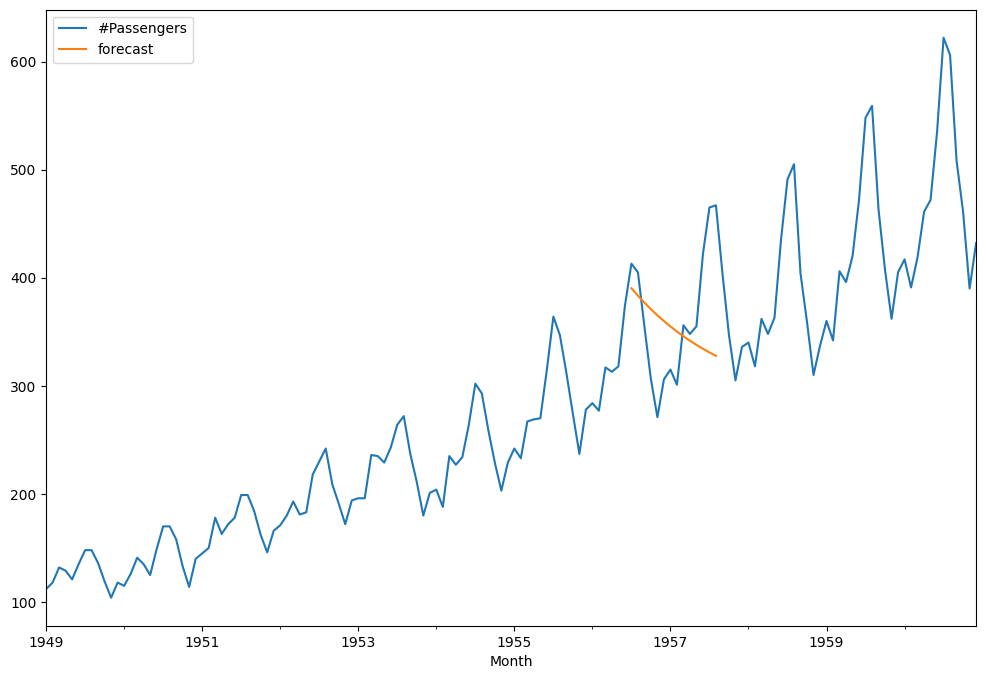

In [33]:
df['forecast']=model_fit.predict(start=90,end=103,dynamic=True)
df[['#Passengers','forecast']].plot(figsize=(12,8))

In [34]:
model=sm.tsa.statespace.SARIMAX(df['#Passengers'],order=(1,0,1),seasonal_order=(1,0,1,12))
results=model.fit()

In [35]:
results.aic

1158.1739456511327

In [36]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                        #Passengers   No. Observations:                  144
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -574.087
Date:                            Mon, 30 Dec 2024   AIC                           1158.174
Time:                                    22:09:16   BIC                           1173.023
Sample:                                01-01-1949   HQIC                          1164.208
                                     - 12-01-1960                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9738      0.015     63.730      0.000       0.944       1.004
ma.L1         -0.2314      0.073     -3.168      0.002      -0.375      -0.088
ar.S.L12       0.9686      0.021     45.355      0.000       0.927       1.010
ma.S.L12      -0.0940      0.109     -0.866      0.387      -0.307       0.119
sigma2       132.3424     14.833      8.922      0.000     103.271     161.414
===================================================================================
Ljung-Box (L1) (Q):                   0.11   Jarque-Bera (JB):                14.34
Prob(Q):                              0.74   Prob(JB):                         0.00
Heteroskedasticity (H):               3.90   Skew:                             0.18
Prob(H) (two-sided):                  0.00   Kurtosis:                         4.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='Month'>

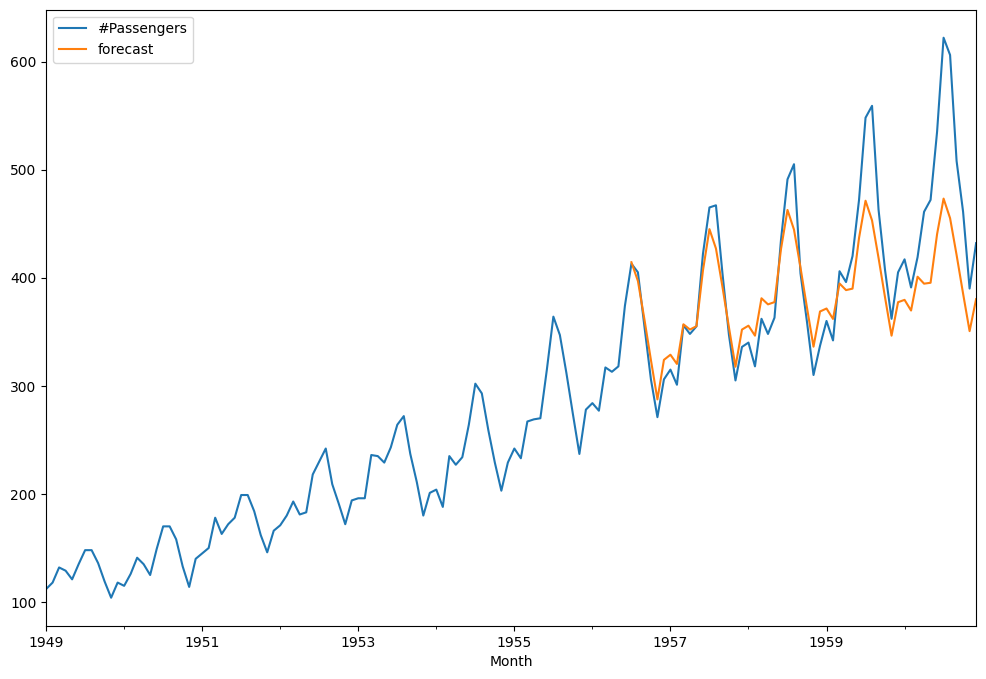

In [37]:
df['forecast']=results.predict(start=90,end=800,dynamic=True)
df[['#Passengers','forecast']].plot(figsize=(12,8))

In [38]:
df

,#Passengers,forecast
Month,,
1949-01-01,112,NaN
1949-02-01,118,NaN
1949-03-01,132,NaN
1949-04-01,129,NaN
1949-05-01,121,NaN
...,...,...
1960-08-01,606,455.072597
1960-09-01,508,421.088441
1960-10-01,461,385.267514


In [39]:
df=df['#Passengers']

In [40]:
df = pd.DataFrame(df)
df

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


<Axes: xlabel='Month'>

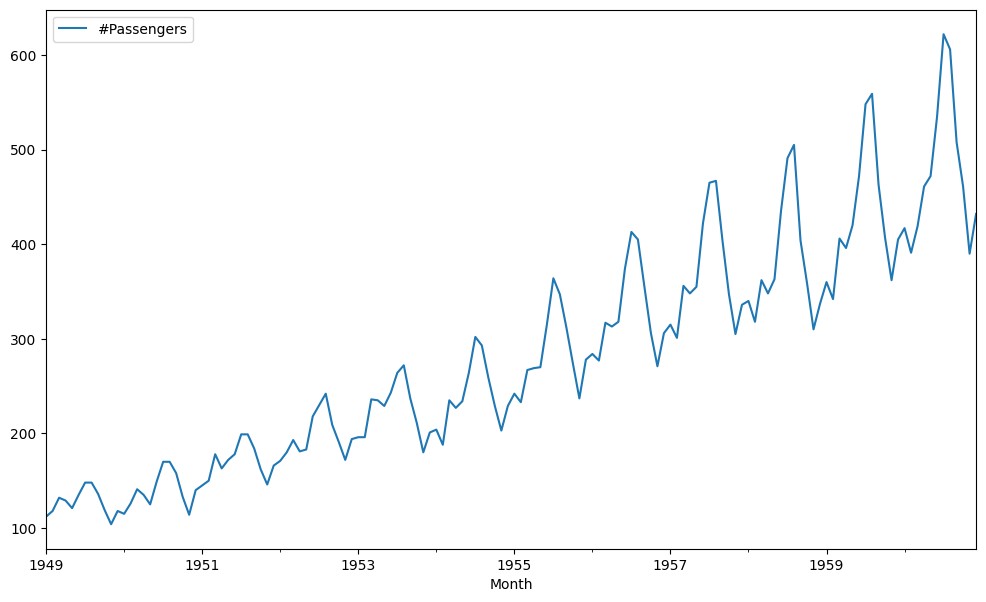

In [41]:
df.plot(figsize=(12,7))

NaN in test['#Passengers']: False
NaN in forecast_inverted: False
Mean Squared Error: 825.2730496312955


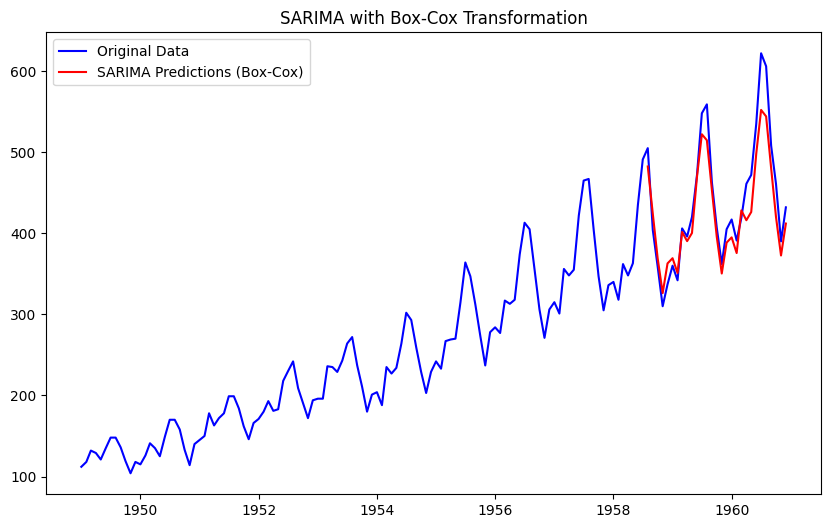

In [42]:
import pandas as pd
import numpy as np
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
values = df['#Passengers']

# Apply Box-Cox Transformation
transformed_values, lambda_boxcox = boxcox(values)

# Add transformed values back to DataFrame for modeling
df['transformed'] = transformed_values

# Split the data into train and test sets
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# SARIMA model fitting
sarima_model = SARIMAX(train['transformed'], order=(1,0,1), seasonal_order=(1,0,1, 12))
sarima_fit = sarima_model.fit(disp=False)

# Forecasting
forecast = sarima_fit.forecast(steps=len(test))

# Inverse Box-Cox Transformation of predictions
forecast_inverted = np.exp(np.log(lambda_boxcox * forecast + 1) / lambda_boxcox)
print("NaN in test['#Passengers']:", test['#Passengers'].isnull().any())
print("NaN in forecast_inverted:", forecast_inverted.isnull().any())
forecast_inverted.fillna(method="ffill", inplace=True)

# Evaluate predictions
mse = mean_squared_error(test['#Passengers'], forecast_inverted)
print(f"Mean Squared Error: {mse}")

# Visualize results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(test.index, forecast_inverted, label="SARIMA Predictions (Box-Cox)", color="red")
plt.legend()
plt.title("SARIMA with Box-Cox Transformation")
plt.show()

NaN in test['#Passengers']: False
NaN in forecast_inverted: False
Mean Squared Error: 825.2730496312955


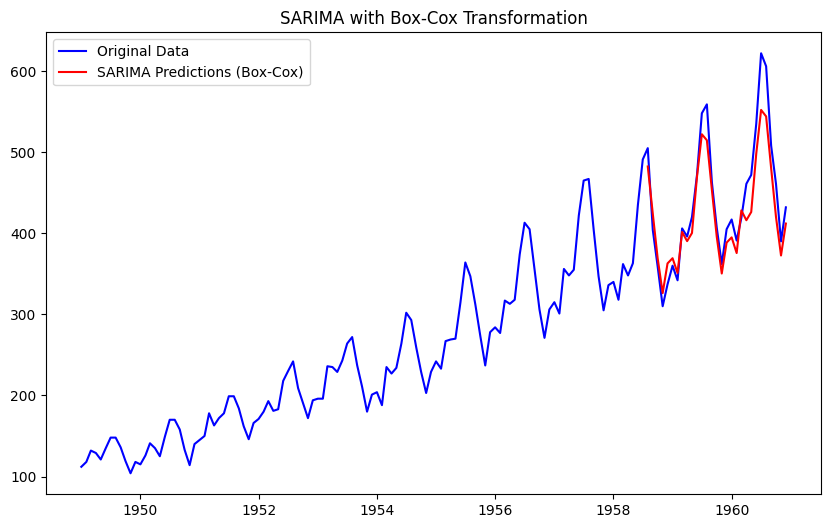

In [43]:

import pandas as pd
import numpy as np
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
values = df['#Passengers']

# Apply Box-Cox Transformation
transformed_values, lambda_boxcox = boxcox(values)

# Add transformed values back to DataFrame for modeling
df['transformed'] = transformed_values

# Split the data into train and test sets
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# SARIMA model fitting
sarima_model = SARIMAX(train['transformed'], order=(1,0,1), seasonal_order=(1,0,1, 12))
sarima_fit = sarima_model.fit(disp=False)

# Forecasting
forecast = sarima_fit.forecast(steps=len(test))

# Inverse Box-Cox Transformation of predictions
forecast_inverted = np.exp(np.log(lambda_boxcox * forecast + 1) / lambda_boxcox)
print("NaN in test['#Passengers']:", test['#Passengers'].isnull().any())
print("NaN in forecast_inverted:", forecast_inverted.isnull().any())
forecast_inverted.fillna(method="ffill", inplace=True)

# Evaluate predictions
mse = mean_squared_error(test['#Passengers'], forecast_inverted)
print(f"Mean Squared Error: {mse}")

# Visualize results
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(test.index, forecast_inverted, label="SARIMA Predictions (Box-Cox)", color="red")
plt.legend()
plt.title("SARIMA with Box-Cox Transformation")
plt.show()


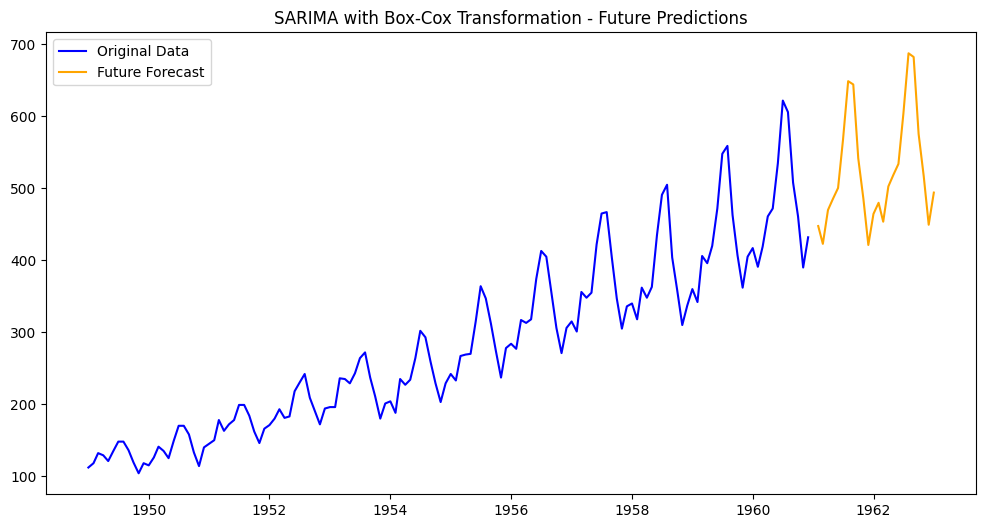

In [44]:
# Fit SARIMA model on the full dataset
sarima_model = SARIMAX(df['transformed'], order=(1,0,1), seasonal_order=(1,0,1, 12))
sarima_fit = sarima_model.fit(disp=False)


# Predict future values (e.g., next 12 months)
future_steps = 24
future_forecast = sarima_fit.forecast(steps=future_steps)

# Inverse Box-Cox Transformation for future predictions
future_forecast_inverted = np.exp(np.log(lambda_boxcox * future_forecast + 1) / lambda_boxcox)

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]

# Combine future dates with predictions
future_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast_inverted})
future_df.set_index('Date', inplace=True)

# Visualize results
plt.figure(figsize=(12, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(future_df.index, future_df['Forecast'], label="Future Forecast", color="orange")
plt.title("SARIMA with Box-Cox Transformation - Future Predictions")
plt.legend()
plt.show()

# Save future predictions to a CSV file
future_df.to_csv("future_predictions-adfuller.csv")


# **Simple aic**

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
SARIMA(0, 0, 0)x(0, 0, 0, 12) - AIC: 816.6327630800849
SARIMA(0, 0, 0)x(0, 0, 1, 12) - AIC: 698.57882663193
SARIMA(0, 0, 0)x(0, 1, 0, 12) - AIC: 54.64946847331751
SARIMA(0, 0, 0)x(0, 1, 1, 12) - AIC: 17.685971804846844
SARIMA(0, 0, 0)x(1, 0, 0, 12) - AIC: 141.63998513933427
SARIMA(0, 0, 0)x(1, 0, 1, 12) - AIC: 104.7095874172073
SARIMA(0, 0, 0)x(1, 1, 0, 12) - AIC: -21.657435069088574
SARIMA(0, 0, 0)x(1, 1, 1, 12) - AIC: -58.77444909849248
SARIMA(0, 0, 0)x(2, 0, 0, 12) - AIC: 65.20949741293356
SARIMA(0, 0, 0)x(2, 0, 1, 12) - AIC: 130.4712478069906
SARIMA(0, 0, 0)x(2, 1, 0, 12) - AIC: -38.2876951667124
SARIMA(0, 0, 0)x(2, 1, 1, 12) - AIC: -62.27045777533412
SARIMA(0, 0, 1)x(0, 0, 0, 12) - AIC: 665.2046371067494
SARIMA(0, 0, 1)x(0, 0, 1, 12) - AIC: 546.13456371981
SARIMA(0, 0, 1)x(0, 1, 0, 12) - AIC: -30.164065885401293
SARIMA(0, 0, 1)x(0, 1, 1, 12) - AIC: -46.269593277922894
SARIMA(0, 0, 1)x(1, 0, 0, 12) - AIC: 43.4494160656162

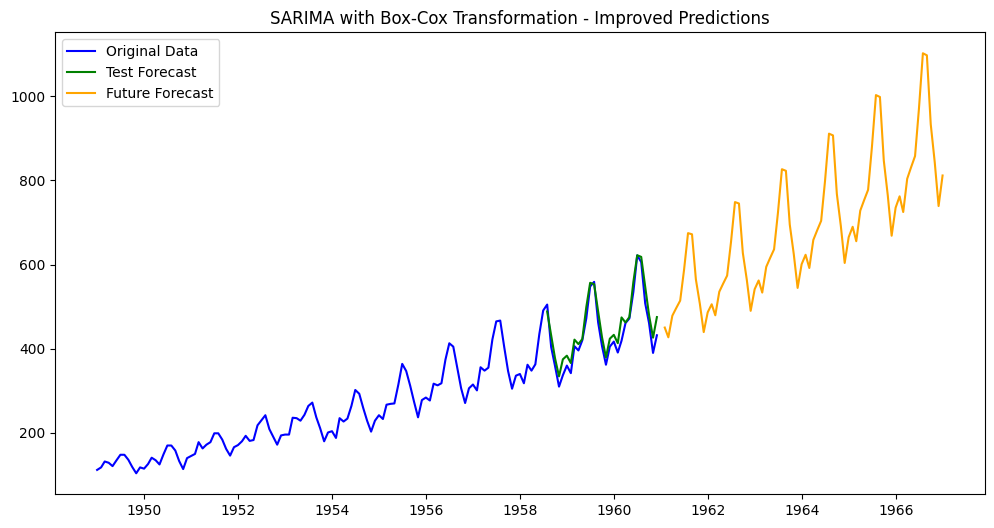

In [45]:

import pandas as pd
import numpy as np
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ensure data is stationary
result = adfuller(df['#Passengers'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# Apply Box-Cox Transformation
values = df['#Passengers']
transformed_values, lambda_boxcox = boxcox(values)
df['transformed'] = transformed_values

# Split the data into train and test sets
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Parameter Tuning for SARIMA
from itertools import product
import statsmodels.api as sm

# Define parameter ranges

p=range(0,3)
d=range(0,2)
q=range(0,2)
P = range(0, 3)
D = range(0, 2)
Q = range(0, 2)
seasonal_period = [12]

# Grid search for best parameters
pdq = list(product(p, d, q))
seasonal_pdq = list(product(P, D, Q, seasonal_period))

best_aic = float('inf')
best_order = None
best_seasonal_order = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = sm.tsa.statespace.SARIMAX(train['transformed'], order=order, seasonal_order=seasonal_order)
            results = model.fit(disp=False)
            print(f"SARIMA{order}x{seasonal_order} - AIC: {results.aic}")
            if results.aic < best_aic:
                best_aic = results.aic
                best_order = order
                best_seasonal_order = seasonal_order
        except:
            continue

print(f"Best SARIMA order: {best_order}, Seasonal order: {best_seasonal_order}")

# Fit SARIMA model with best parameters
sarima_model = SARIMAX(train['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit = sarima_model.fit(disp=False)

# Forecasting
forecast = sarima_fit.forecast(steps=len(test))

# Inverse Box-Cox Transformation
forecast_inverted = np.exp(np.log(lambda_boxcox * forecast + 1) / lambda_boxcox)

# Handle NaN values in predictions
forecast_inverted = pd.Series(forecast_inverted).fillna(method="ffill").fillna(method="bfill")

# Evaluate predictions
mse = mean_squared_error(test['#Passengers'], forecast_inverted)
print(f"Mean Squared Error: {mse}")

# Fit SARIMA on the full dataset for future predictions
sarima_model_full = SARIMAX(df['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit_full = sarima_model_full.fit(disp=False)

# Predict future values (next 72 months)
future_steps = 72
future_forecast = sarima_fit_full.forecast(steps=future_steps)

# Inverse Box-Cox Transformation for future predictions
future_forecast_inverted = np.exp(np.log(lambda_boxcox * future_forecast + 1) / lambda_boxcox)

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]

# Combine future dates with predictions
future_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast_inverted})
future_df.set_index('Date', inplace=True)

# Visualize results
plt.figure(figsize=(12, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(test.index, forecast_inverted, label="Test Forecast", color="green")
plt.plot(future_df.index, future_df['Forecast'], label="Future Forecast", color="orange")
plt.title("SARIMA with Box-Cox Transformation - Improved Predictions")
plt.legend()
plt.show()


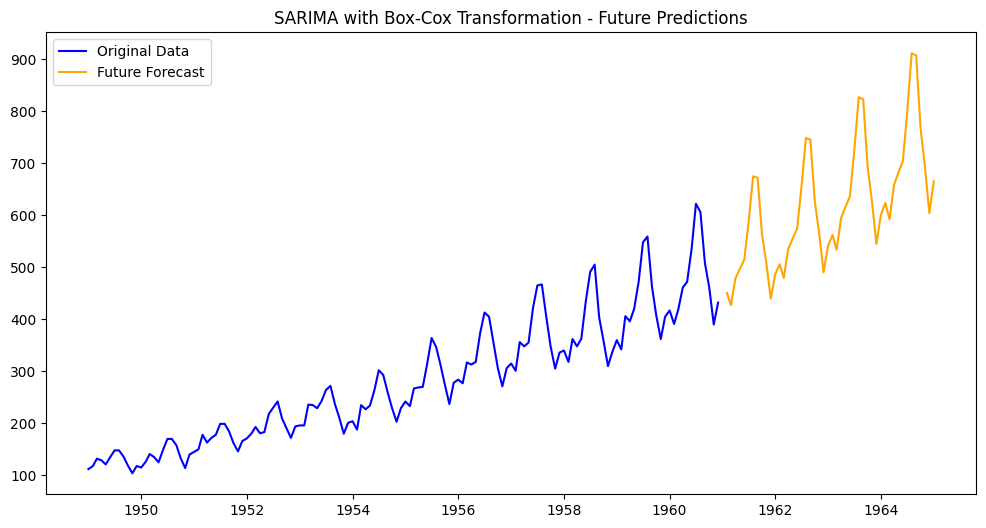

In [46]:
# Fit SARIMA model on the full dataset
sarima_model = SARIMAX(df['transformed'], order=(2, 1, 1), seasonal_order=(0, 1, 1, 12))
sarima_fit = sarima_model.fit(disp=False)


# Predict future values (e.g., next 12 months)
future_steps = 48
future_forecast = sarima_fit.forecast(steps=future_steps)

# Inverse Box-Cox Transformation for future predictions
future_forecast_inverted = np.exp(np.log(lambda_boxcox * future_forecast + 1) / lambda_boxcox)

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]

# Combine future dates with predictions
future_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast_inverted})
future_df.set_index('Date', inplace=True)

# Visualize results
plt.figure(figsize=(12, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(future_df.index, future_df['Forecast'], label="Future Forecast", color="orange")
plt.title("SARIMA with Box-Cox Transformation - Future Predictions")
plt.legend()
plt.show()

# Save future predictions to a CSV file
future_df.to_csv("future_predictions-aic-air_passengers..csv")


# **AIC with formula**

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
SARIMA(0, 0, 0)x(0, 0, 0, 12) - AIC: 816.6327630800849
SARIMA(0, 0, 0)x(0, 0, 1, 12) - AIC: 698.57882663193
SARIMA(0, 0, 0)x(0, 1, 0, 12) - AIC: 54.64946847331751
SARIMA(0, 0, 0)x(0, 1, 1, 12) - AIC: 17.685971804846844
SARIMA(0, 0, 0)x(1, 0, 0, 12) - AIC: 141.63998513933427
SARIMA(0, 0, 0)x(1, 0, 1, 12) - AIC: 104.7095874172073
SARIMA(0, 0, 0)x(1, 1, 0, 12) - AIC: -21.657435069088574
SARIMA(0, 0, 0)x(1, 1, 1, 12) - AIC: -58.77444909849248
SARIMA(0, 0, 0)x(2, 0, 0, 12) - AIC: 65.20949741293356
SARIMA(0, 0, 0)x(2, 0, 1, 12) - AIC: 130.4712478069906
SARIMA(0, 0, 0)x(2, 1, 0, 12) - AIC: -38.2876951667124
SARIMA(0, 0, 0)x(2, 1, 1, 12) - AIC: -62.27045777533412
SARIMA(0, 0, 1)x(0, 0, 0, 12) - AIC: 665.2046371067494
SARIMA(0, 0, 1)x(0, 0, 1, 12) - AIC: 546.13456371981
SARIMA(0, 0, 1)x(0, 1, 0, 12) - AIC: -30.164065885401293
SARIMA(0, 0, 1)x(0, 1, 1, 12) - AIC: -46.269593277922894
SARIMA(0, 0, 1)x(1, 0, 0, 12) - AIC: 43.4494160656162

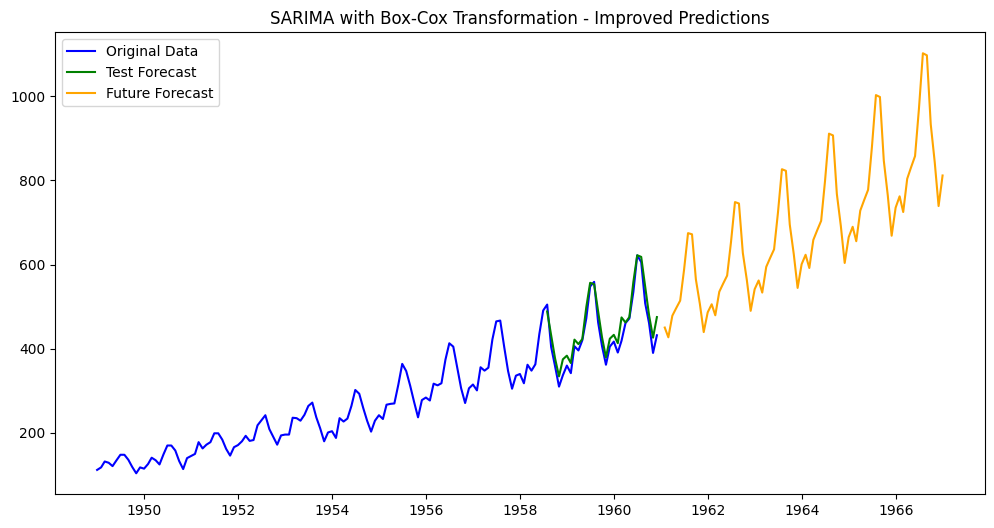

In [47]:
import pandas as pd
import numpy as np
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ensure data is stationary
result = adfuller(df['#Passengers'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# Apply Box-Cox Transformation
values = df['#Passengers']
transformed_values, lambda_boxcox = boxcox(values)
df['transformed'] = transformed_values

# Split the data into train and test sets
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Parameter Tuning for SARIMA
from itertools import product
import statsmodels.api as sm

# Define parameter ranges
p = range(0, 3)
d = range(0, 2)
q = range(0, 2)
P = range(0, 3)
D = range(0, 2)
Q = range(0, 2)
seasonal_period = [12]

# Grid search for best parameters
pdq = list(product(p, d, q))
seasonal_pdq = list(product(P, D, Q, seasonal_period))

best_aic = float('inf')
best_order = None
best_seasonal_order = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = sm.tsa.statespace.SARIMAX(train['transformed'], order=order, seasonal_order=seasonal_order)
            results = model.fit(disp=False)

            # Manually calculate AIC
            log_likelihood = results.llf
            num_params = results.df_model  # Correct way to get number of parameters
            num_obs = len(train['transformed'])
            aic = 2 * num_params - 2 * log_likelihood  # AIC formula

            print(f"SARIMA{order}x{seasonal_order} - AIC: {aic}")

            # Track the best AIC
            if aic < best_aic:
                best_aic = aic
                best_order = order
                best_seasonal_order = seasonal_order
        except:
            continue

print(f"Best SARIMA order: {best_order}, Seasonal order: {best_seasonal_order}, AIC: {best_aic}")

# Fit SARIMA model with best parameters
sarima_model = SARIMAX(train['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit = sarima_model.fit(disp=False)

# Forecasting
forecast = sarima_fit.forecast(steps=len(test))

# Inverse Box-Cox Transformation
forecast_inverted = np.exp(np.log(lambda_boxcox * forecast + 1) / lambda_boxcox)

# Handle NaN values in predictions
forecast_inverted = pd.Series(forecast_inverted).fillna(method="ffill").fillna(method="bfill")

# Evaluate predictions
mse = mean_squared_error(test['#Passengers'], forecast_inverted)
print(f"Mean Squared Error: {mse}")

# Fit SARIMA on the full dataset for future predictions
sarima_model_full = SARIMAX(df['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit_full = sarima_model_full.fit(disp=False)

# Predict future values (next 72 months)
future_steps = 72
future_forecast = sarima_fit_full.forecast(steps=future_steps)

# Inverse Box-Cox Transformation for future predictions
future_forecast_inverted = np.exp(np.log(lambda_boxcox * future_forecast + 1) / lambda_boxcox)

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]

# Combine future dates with predictions
future_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast_inverted})
future_df.set_index('Date', inplace=True)

# Visualize results
plt.figure(figsize=(12, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(test.index, forecast_inverted, label="Test Forecast", color="green")
plt.plot(future_df.index, future_df['Forecast'], label="Future Forecast", color="orange")
plt.title("SARIMA with Box-Cox Transformation - Improved Predictions")
plt.legend()
plt.show()


# **simple BIC**

ADF Statistic: 0.8153688792060498
p-value: 0.991880243437641
SARIMA(0, 0, 0)x(0, 0, 0, 12) - BIC: 819.3776952084482
SARIMA(0, 0, 0)x(0, 0, 1, 12) - BIC: 704.0686908886565
SARIMA(0, 0, 0)x(0, 1, 0, 12) - BIC: 57.28419746154715
SARIMA(0, 0, 0)x(0, 1, 1, 12) - BIC: 22.955429781306115
SARIMA(0, 0, 0)x(1, 0, 0, 12) - BIC: 147.12984939606076
SARIMA(0, 0, 0)x(1, 0, 1, 12) - BIC: 112.94438380229705
SARIMA(0, 0, 0)x(1, 1, 0, 12) - BIC: -16.387977092629303
SARIMA(0, 0, 0)x(1, 1, 1, 12) - BIC: -50.87026213380358
SARIMA(0, 0, 0)x(2, 0, 0, 12) - BIC: 73.4442937980233
SARIMA(0, 0, 0)x(2, 0, 1, 12) - BIC: 141.4509763204436
SARIMA(0, 0, 0)x(2, 1, 0, 12) - BIC: -30.383508202023496
SARIMA(0, 0, 0)x(2, 1, 1, 12) - BIC: -51.73154182241558
SARIMA(0, 0, 1)x(0, 0, 0, 12) - BIC: 670.6945013634759
SARIMA(0, 0, 1)x(0, 0, 1, 12) - BIC: 554.3693601048998
SARIMA(0, 0, 1)x(0, 1, 0, 12) - BIC: -24.89460790894202
SARIMA(0, 0, 1)x(0, 1, 1, 12) - BIC: -38.36540631323399
SARIMA(0, 0, 1)x(1, 0, 0, 12) - BIC: 51.684212450

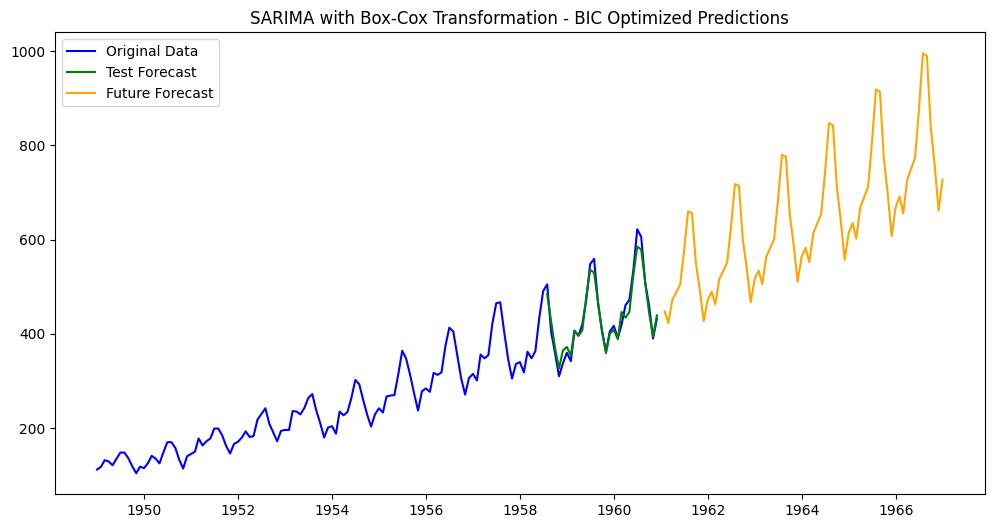

In [48]:
import pandas as pd
import numpy as np
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Ensure data is stationary
result = adfuller(df['#Passengers'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# Apply Box-Cox Transformation
values = df['#Passengers']
transformed_values, lambda_boxcox = boxcox(values)
df['transformed'] = transformed_values

# Split the data into train and test sets
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Parameter Tuning for SARIMA
from itertools import product
import statsmodels.api as sm

# Define parameter ranges
p = range(0, 3)
d = range(0, 2)
q = range(0, 2)
P = range(0, 3)
D = range(0, 2)
Q = range(0, 2)
seasonal_period = [12]

# Grid search for best parameters
pdq = list(product(p, d, q))
seasonal_pdq = list(product(P, D, Q, seasonal_period))

best_bic = float('inf')
best_order = None
best_seasonal_order = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            model = sm.tsa.statespace.SARIMAX(train['transformed'], order=order, seasonal_order=seasonal_order)
            results = model.fit(disp=False)
            print(f"SARIMA{order}x{seasonal_order} - BIC: {results.bic}")
            if results.bic < best_bic:
                best_bic = results.bic
                best_order = order
                best_seasonal_order = seasonal_order
        except:
            continue

print(f"Best SARIMA order: {best_order}, Seasonal order: {best_seasonal_order}")

# Fit SARIMA model with best parameters
sarima_model = SARIMAX(train['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit = sarima_model.fit(disp=False)

# Forecasting
forecast = sarima_fit.forecast(steps=len(test))

# Inverse Box-Cox Transformation
forecast_inverted = np.exp(np.log(lambda_boxcox * forecast + 1) / lambda_boxcox)

# Handle NaN values in predictions
forecast_inverted = pd.Series(forecast_inverted).fillna(method="ffill").fillna(method="bfill")

# Evaluate predictions
mse = mean_squared_error(test['#Passengers'], forecast_inverted)
print(f"Mean Squared Error: {mse}")

# Fit SARIMA on the full dataset for future predictions
sarima_model_full = SARIMAX(df['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit_full = sarima_model_full.fit(disp=False)

# Predict future values (next 72 months)
future_steps = 72
future_forecast = sarima_fit_full.forecast(steps=future_steps)

# Inverse Box-Cox Transformation for future predictions
future_forecast_inverted = np.exp(np.log(lambda_boxcox * future_forecast + 1) / lambda_boxcox)

# Create future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]

# Combine future dates with predictions
future_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast_inverted})
future_df.set_index('Date', inplace=True)

# Visualize results
plt.figure(figsize=(12, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(test.index, forecast_inverted, label="Test Forecast", color="green")
plt.plot(future_df.index, future_df['Forecast'], label="Future Forecast", color="orange")
plt.title("SARIMA with Box-Cox Transformation - BIC Optimized Predictions")
plt.legend()
plt.show()
# Save future predictions to a CSV file
future_df.to_csv("future_predictions-bic-air_passengers.csv")


# **BIC with formaula**

SARIMA(0, 0, 0)x(0, 0, 0, 12) - BIC: 819.3776952084482
SARIMA(0, 0, 0)x(0, 0, 1, 12) - BIC: 704.0686908886565
SARIMA(0, 0, 0)x(0, 1, 0, 12) - BIC: 57.394400601680765
SARIMA(0, 0, 0)x(0, 1, 1, 12) - BIC: 23.175836061573346
SARIMA(0, 0, 0)x(1, 0, 0, 12) - BIC: 147.12984939606076
SARIMA(0, 0, 0)x(1, 0, 1, 12) - BIC: 112.94438380229705
SARIMA(0, 0, 0)x(1, 1, 0, 12) - BIC: -16.167570812362072
SARIMA(0, 0, 0)x(1, 1, 1, 12) - BIC: -50.53965271340273
SARIMA(0, 0, 0)x(2, 0, 0, 12) - BIC: 73.4442937980233
SARIMA(0, 0, 0)x(2, 0, 1, 12) - BIC: 141.4509763204436
SARIMA(0, 0, 0)x(2, 1, 0, 12) - BIC: -30.052898781622652
SARIMA(0, 0, 0)x(2, 1, 1, 12) - BIC: -51.290729261881125
SARIMA(0, 0, 1)x(0, 0, 0, 12) - BIC: 670.6945013634759
SARIMA(0, 0, 1)x(0, 0, 1, 12) - BIC: 554.3693601048998
SARIMA(0, 0, 1)x(0, 1, 0, 12) - BIC: -24.674201628674794
SARIMA(0, 0, 1)x(0, 1, 1, 12) - BIC: -38.03479689283314
SARIMA(0, 0, 1)x(1, 0, 0, 12) - BIC: 51.684212450705964
SARIMA(0, 0, 1)x(1, 0, 1, 12) - BIC: 88.29892771364

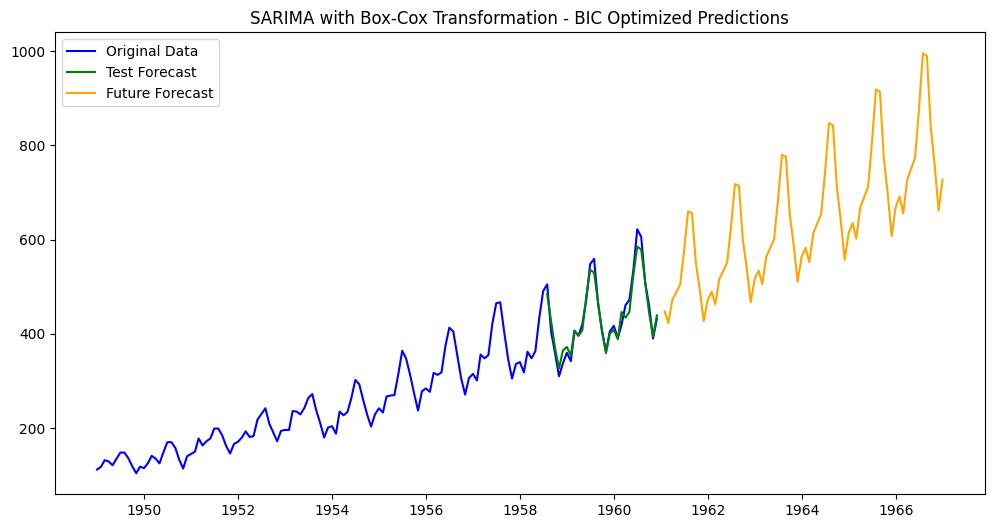

In [49]:
import pandas as pd
import numpy as np
from scipy.stats import boxcox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from itertools import product
import matplotlib.pyplot as plt

# Load your dataset
# Assuming df['#Passengers'] is the target series and Date is the index.
values = df['#Passengers']

# Apply Box-Cox Transformation to stabilize variance
transformed_values, lambda_boxcox = boxcox(values)
df['transformed'] = transformed_values

# Train-test split
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Define parameter ranges for SARIMA
p = range(0, 3)
d = range(0, 2)
q = range(0, 2)
P = range(0, 3)
D = range(0, 2)
Q = range(0, 2)
seasonal_period = [12]

# Grid search for best BIC
pdq = list(product(p, d, q))
seasonal_pdq = list(product(P, D, Q, seasonal_period))

best_bic = float('inf')
best_order = None
best_seasonal_order = None

for order in pdq:
    for seasonal_order in seasonal_pdq:
        try:
            # Fit SARIMA model
            model = SARIMAX(train['transformed'], order=order, seasonal_order=seasonal_order)
            results = model.fit(disp=False)

            # Manually calculate BIC
            log_likelihood = results.llf
            num_params = results.df_model
            num_obs = len(train['transformed'])
            bic = num_params * np.log(num_obs) - 2 * log_likelihood

            print(f"SARIMA{order}x{seasonal_order} - BIC: {bic}")

            # Track the best BIC
            if bic < best_bic:
                best_bic = bic
                best_order = order
                best_seasonal_order = seasonal_order
        except:
            continue

print(f"Best SARIMA order: {best_order}, Seasonal order: {best_seasonal_order}, BIC: {best_bic}")

# Fit SARIMA model with the best parameters
sarima_model = SARIMAX(train['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit = sarima_model.fit(disp=False)

# Forecast for the test set
forecast = sarima_fit.forecast(steps=len(test))

# Inverse Box-Cox Transformation
forecast_inverted = np.exp(np.log(lambda_boxcox * forecast + 1) / lambda_boxcox)

# Evaluate the model
mse = mean_squared_error(test['#Passengers'], forecast_inverted)
print(f"Mean Squared Error: {mse}")

# Fit the best SARIMA model on the full dataset for future forecasting
sarima_model_full = SARIMAX(df['transformed'], order=best_order, seasonal_order=best_seasonal_order)
sarima_fit_full = sarima_model_full.fit(disp=False)

# Predict future values (next 72 months)
future_steps = 72
future_forecast = sarima_fit_full.forecast(steps=future_steps)

# Inverse Box-Cox Transformation for future predictions
future_forecast_inverted = np.exp(np.log(lambda_boxcox * future_forecast + 1) / lambda_boxcox)

# Generate future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=future_steps + 1, freq='M')[1:]

# Combine future predictions into a DataFrame
future_df = pd.DataFrame({'Date': future_dates, 'Forecast': future_forecast_inverted})
future_df.set_index('Date', inplace=True)

# Visualize results
plt.figure(figsize=(12, 6))
plt.plot(df.index, values, label="Original Data", color="blue")
plt.plot(test.index, forecast_inverted, label="Test Forecast", color="green")
plt.plot(future_df.index, future_df['Forecast'], label="Future Forecast", color="orange")
plt.title("SARIMA with Box-Cox Transformation - BIC Optimized Predictions")
plt.legend()
plt.show()


In [50]:
# Best SARIMA order: (1, 1, 0)x(0, 1, 1, 12), BIC: -201.4033079671434
# SARIMA(2, 1, 1)x(0, 1, 1, 12) - BIC: -196.12247083730344
# Best SARIMA order:(2, 1, 1)x(0, 1, 1, 12) - AIC: -209.8471314791197
# SARIMA(1, 1, 0)x(0, 1, 1, 12) - AIC: -209.63810435223314

In [51]:
# SARIMA(1, 1, 0)x(0, 1, 1, 12) - BIC: -201.76318591238032
#  SARIMA order: (1, 1, 0), Seasonal order: (0, 1, 1, 12), BIC: -201.4033079671434